## Perturbation

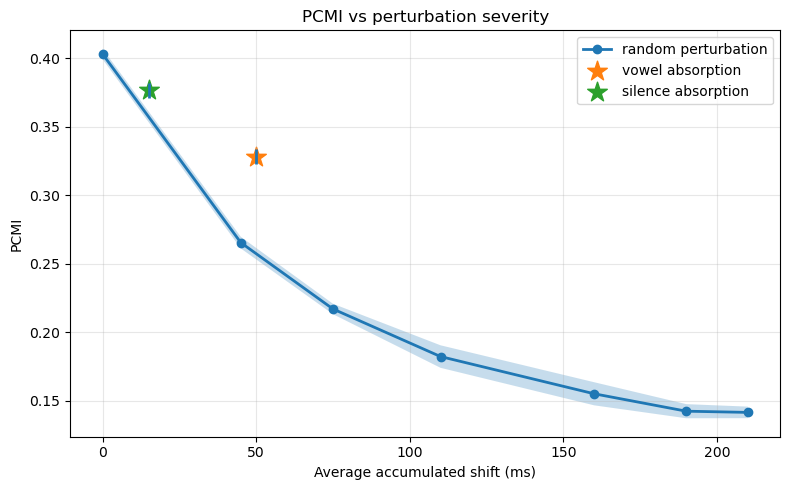

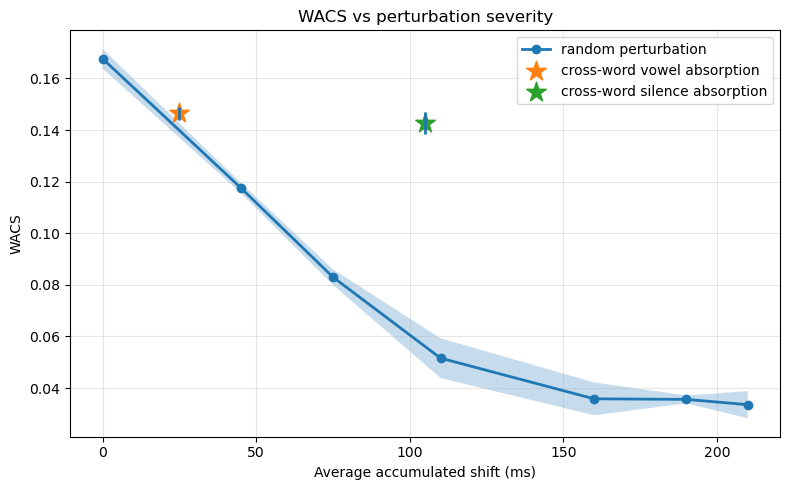

In [45]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
with open("results/perturbation.json") as fp:
    results=json.load(fp)

# ---------------------------------------------------------
# AAS MAP
# ---------------------------------------------------------
aas_map={
    "tg":0,
    "tg_50":45,
    "tg_100":75,
    "tg_200":110,
    "tg_500":160,
    "tg_1000":190,
    "tg_2000":210,

    # systematic perturbations
    "tg_VC":50,
    "tg_VC_boundary":25,
    "tg_SIL":15,
    "tg_SIL_boundary":105,
}

# ---------------------------------------------------------
# DISPLAY NAMES
# ---------------------------------------------------------
special_names={
    "tg_VC":"vowel absorption",
    "tg_VC_boundary":"cross-word vowel absorption",
    "tg_SIL":"silence absorption",
    "tg_SIL_boundary":"cross-word silence absorption",
}

line_keys=[
    "tg",
    "tg_50",
    "tg_100",
    "tg_200",
    "tg_500",
    "tg_1000",
    "tg_2000",
]

special_keys=[
    "tg_VC",
    "tg_VC_boundary",
    "tg_SIL",
    "tg_SIL_boundary",
]

# ---------------------------------------------------------
# EXTRACT
# ---------------------------------------------------------
def get_metric_stats(metric_name):

    xs=[]
    means=[]
    stds=[]

    for k in line_keys:

        vals=[
            r[metric_name]["nmi"]
            if metric_name=="nmi"
            else r[metric_name]["wacs"]
            for r in results[k]
        ]

        xs.append(aas_map[k])
        means.append(np.mean(vals))
        stds.append(np.std(vals))

    return (
        np.array(xs),
        np.array(means),
        np.array(stds)
    )

# ---------------------------------------------------------
# PLOT FUNCTION
# ---------------------------------------------------------
def plot_metric(metric_name,ylabel):

    plt.figure(figsize=(8,5))

    # -------------------------------------
    # main perturbation curve
    # -------------------------------------
    xs,means,stds=get_metric_stats(metric_name)

    order=np.argsort(xs)

    xs=xs[order]
    means=means[order]
    stds=stds[order]

    plt.plot(
        xs,
        means,
        marker="o",
        linewidth=2,
        label="random perturbation"
    )

    plt.fill_between(
        xs,
        means-stds,
        means+stds,
        alpha=0.25
    )

    # -------------------------------------
    # systematic perturbations
    # -------------------------------------
    for k in special_keys:

        if metric_name == "nmi" and "boundary" in k:
            continue

        if metric_name == "wacs" and "boundary" not in k:
            continue

        vals=[
            r[metric_name]["nmi"]
            if metric_name=="nmi"
            else r[metric_name]["wacs"]
            for r in results[k]
        ]

        mean=np.mean(vals)
        std=np.std(vals)

        x=aas_map[k]

        plt.scatter(
            [x],
            [mean],
            marker='*',
            s=220,
            label=special_names[k],
        )

        plt.vlines(
            x,
            mean-std,
            mean+std,
            linewidth=2
        )

    # -------------------------------------
    # cosmetics
    # -------------------------------------
    plt.xlabel("Average accumulated shift (ms)")
    plt.ylabel(ylabel)

    plt.title(f"{ylabel} vs perturbation severity")

    plt.grid(True,alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"results/plots/perturb_{ylabel}.png", dpi=200)
    plt.show()

# ---------------------------------------------------------
# PLOTS
# ---------------------------------------------------------
plot_metric("nmi","PCMI")
plot_metric("wacs","WACS")

## Layer tuning

In [46]:
import os,json
import numpy as np
import matplotlib.pyplot as plt

with open("results/layer_tuning.json") as fp:
    results=json.load(fp)

os.makedirs(
    "results/plots",
    exist_ok=True
)

tg_order=[
    "tg",
    "tg_50",
    "tg_100",
    "tg_200",
    "tg_500",
    "tg_1000",
    "tg_2000"
]

aas_map={
    "tg":0,
    "tg_50":45,
    "tg_100":75,
    "tg_200":110,
    "tg_500":160,
    "tg_1000":190,
    "tg_2000":210,
}

for model,model_data in results.items():

    layers=sorted([
        int(k.split("_")[-1])
        for k in model_data.keys()
    ])

    fig,axes=plt.subplots(
        1,
        2,
        figsize=(14,5),
        sharex=True
    )

    # -------------------------------------------------
    # PCMI
    # -------------------------------------------------
    ax=axes[0]

    for tg_name in tg_order:

        means=[]
        stds=[]

        for layer in layers:

            runs=model_data[
                f"layer_{layer}"
            ][tg_name]

            vals=[
                r["nmi"]["nmi"]
                for r in runs
                if r["nmi"] is not None
            ]

            if len(vals)>0:

                means.append(
                    np.mean(vals)
                )

                stds.append(
                    np.std(vals)
                )

            else:

                means.append(np.nan)
                stds.append(np.nan)

        means=np.array(means)
        stds=np.array(stds)

        label=f"{aas_map[tg_name]} ms"

        ax.plot(
            layers,
            means,
            marker="o",
            label=label
        )

        ax.fill_between(
            layers,
            means-stds,
            means+stds,
            alpha=0.2
        )

    ax.set_xlabel("Layer")
    ax.set_ylabel("PCMI")
    ax.set_title("PCMI")
    ax.grid(True,alpha=0.3)
    ax.legend(
        title="AAS",
        fontsize=8
    )

    # -------------------------------------------------
    # WACS
    # -------------------------------------------------
    ax=axes[1]

    for tg_name in tg_order:

        means=[]
        stds=[]

        for layer in layers:

            runs=model_data[
                f"layer_{layer}"
            ][tg_name]

            vals=[
                r["wacs"]["wacs"]
                for r in runs
                if r["wacs"] is not None
            ]

            if len(vals)>0:

                means.append(
                    np.mean(vals)
                )

                stds.append(
                    np.std(vals)
                )

            else:

                means.append(np.nan)
                stds.append(np.nan)

        means=np.array(means)
        stds=np.array(stds)

        label=f"{aas_map[tg_name]} ms"

        ax.plot(
            layers,
            means,
            marker="o",
            label=label
        )

        ax.fill_between(
            layers,
            means-stds,
            means+stds,
            alpha=0.2
        )

    ax.set_xlabel("Layer")
    ax.set_ylabel("WACS")
    ax.set_title("WACS")
    ax.grid(True,alpha=0.3)
    ax.legend(
        title="AAS",
        fontsize=8
    )

    fig.suptitle(
        f"{model.split('/')[-1]} : layer analysis",
        fontsize=14
    )

    plt.tight_layout()

    out_path=os.path.join(
        "results/plots",
        f"{model.split('/')[-1]}_layers.png"
    )

    plt.savefig(
        out_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    print(
        "saved ->",
        out_path
    )

saved -> results/plots/wav2vec2-large-xlsr-53_layers.png
saved -> results/plots/mms-300m_layers.png


## Multilingual Evalution

facebook/mms-300m random PCMI 0.09071798316356806 0.016586105809594673
facebook/mms-300m mfa PCMI 0.24659800533529191 0.10510582498391513
facebook/mms-300m mms-300m-ipa PCMI 0.23893716916753688 0.02779243614324194
facebook/mms-300m w2v2-lv-60-espeak-ipa PCMI 0.23709357018411978 0.025185891028626613
facebook/wav2vec2-large-xlsr-53 random PCMI 0.09327523888036626 0.015877206495839385
facebook/wav2vec2-large-xlsr-53 mfa PCMI 0.23102839461806413 0.09492607498387781
facebook/wav2vec2-large-xlsr-53 mms-300m-ipa PCMI 0.22622472733214855 0.025627482269796685
facebook/wav2vec2-large-xlsr-53 w2v2-lv-60-espeak-ipa PCMI 0.22493331753723242 0.023415984632047436
facebook/mms-300m random WACS 0.022370569587600808 0.014221026436246701
facebook/mms-300m mfa WACS 0.143394157643965 0.07722348073388516
facebook/mms-300m mms-300m-ipa WACS 0.19495534541612158 0.024974148380713178
facebook/mms-300m w2v2-lv-60-espeak-ipa WACS 0.19309601151490025 0.025858090099243874
facebook/mms-300m qwen3-FA WACS 0.205080456

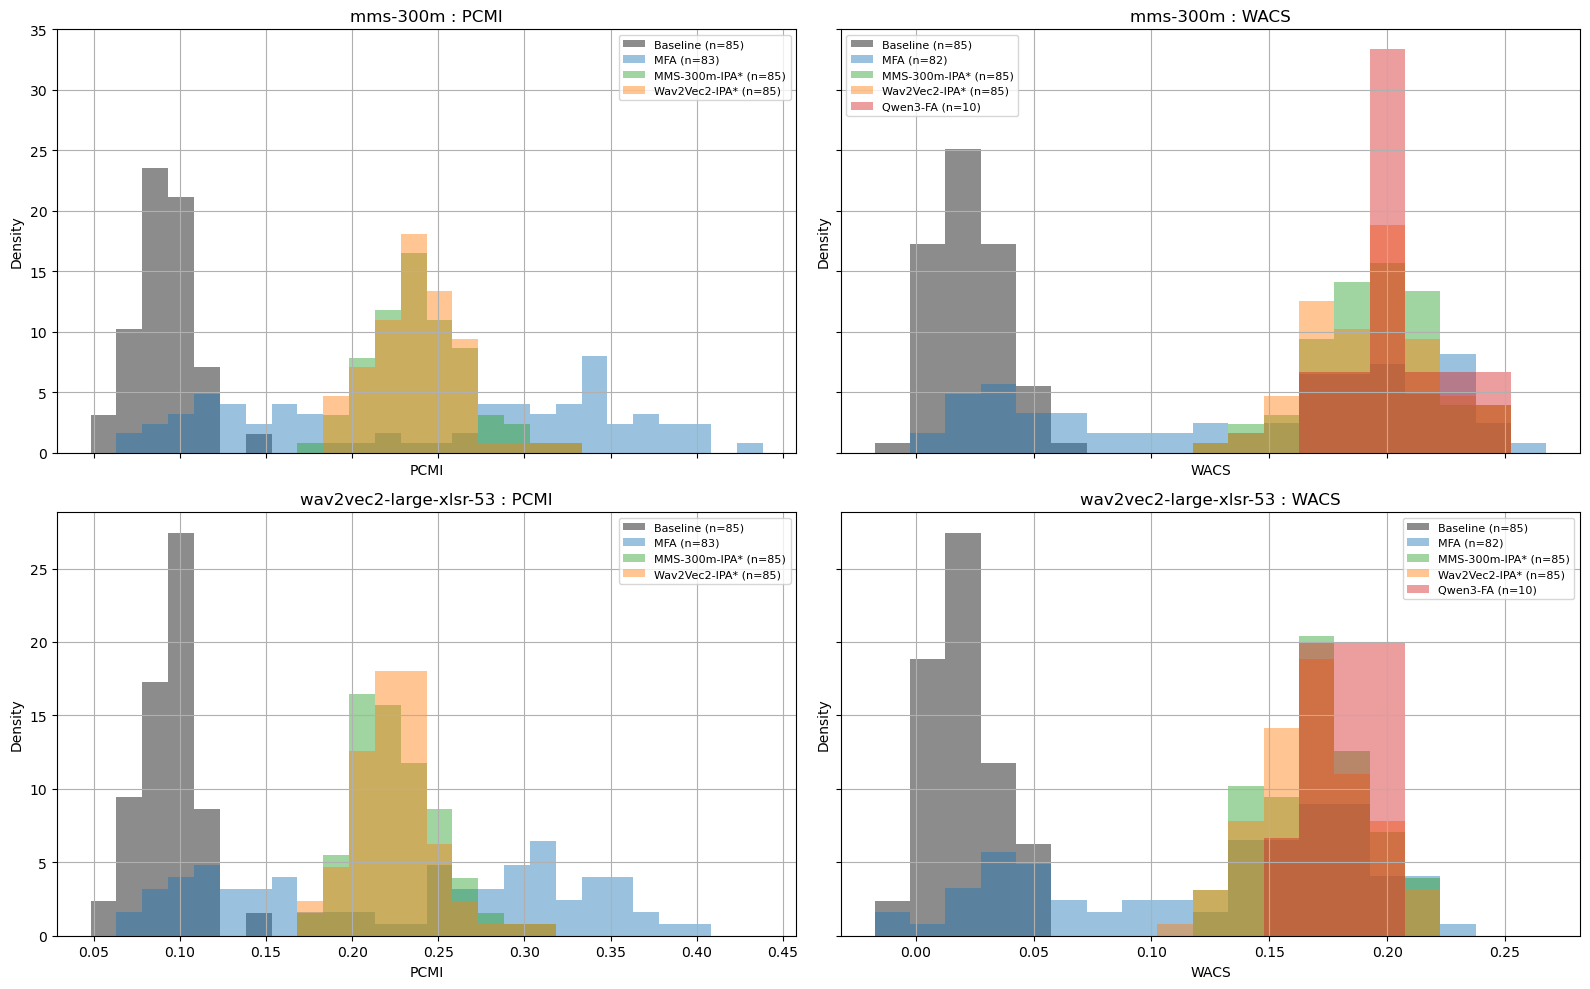

In [43]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
ALIGN_MODELS=[
    "random",
    "mfa",
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
    "qwen3-FA",
]

DISPLAY_NAMES={
    "random":"Baseline",
    "mfa":"MFA",
    "mms-300m-ipa":"MMS-300m-IPA*",
    "w2v2-lv-60-espeak-ipa":"Wav2Vec2-IPA*",
    "qwen3-FA":"Qwen3-FA",
}

EMB_MODELS=[
    "facebook/mms-300m",
    "facebook/wav2vec2-large-xlsr-53",
]

COLORS={
    "random":"black",
    "mfa":"tab:blue",
    "mms-300m-ipa":"tab:green",
    "w2v2-lv-60-espeak-ipa":"tab:orange",
    "qwen3-FA":"tab:red",
}

BIN_WIDTH=0.015

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
all_results={}

for align_model in ALIGN_MODELS:

    path=os.path.join(
        "results",
        align_model,
        "alignment_results.json"
    )

    if not os.path.exists(path):
        continue

    with open(path) as fp:
        all_results[align_model]=json.load(fp)

# ---------------------------------------------------------
# COLLECT VALUES
# ---------------------------------------------------------
metrics={
    "nmi":{},
    "wacs":{},
}

for metric in ["nmi","wacs"]:

    for emb_model in EMB_MODELS:

        metrics[metric][emb_model]={}

        for align_model in ALIGN_MODELS:

            vals=[]

            if align_model not in all_results:
                continue

            for lang,lang_data in all_results[align_model].items():

                if emb_model not in lang_data:
                    continue

                x=lang_data[emb_model]

                if x is None or x[metric] is None:
                    continue

                vals.append(
                    x[metric][metric]
                )

            metrics[metric][emb_model][align_model]=vals

# ---------------------------------------------------------
# GLOBAL BINS
# ---------------------------------------------------------
all_nmi=[]
all_wacs=[]

for emb_model in EMB_MODELS:

    for align_model in ALIGN_MODELS:

        all_nmi.extend(
            metrics["nmi"][emb_model].get(align_model,[])
        )

        all_wacs.extend(
            metrics["wacs"][emb_model].get(align_model,[])
        )

nmi_bins=np.arange(
    min(all_nmi),
    max(all_nmi)+BIN_WIDTH,
    BIN_WIDTH
)

wacs_bins=np.arange(
    min(all_wacs),
    max(all_wacs)+BIN_WIDTH,
    BIN_WIDTH
)

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------
fig,axes=plt.subplots(
    2,
    2,
    figsize=(16,10),
    sharex="col",
    sharey="row"
)

# =========================================================
# PCMI
# =========================================================
for row,emb_model in enumerate(EMB_MODELS):

    ax=axes[row,0]

    for align_model in ALIGN_MODELS:

        vals=metrics["nmi"][emb_model].get(
            align_model,
            []
        )

        if len(vals)==0:
            continue

        ax.hist(
            vals,
            bins=nmi_bins,
            alpha=0.45,
            density=True,
            color=COLORS[align_model],
            label=f"{DISPLAY_NAMES[align_model]} (n={len(vals)})"
        )

        print(
            emb_model,
            align_model,
            "PCMI",
            np.mean(vals),
            np.std(vals)
        )

    ax.set_title(
        f"{emb_model.split('/')[-1]} : PCMI"
    )

    ax.set_xlabel("PCMI")
    ax.set_ylabel("Density")
    ax.grid(True)
    ax.legend(fontsize=8)

# =========================================================
# WACS
# =========================================================
for row,emb_model in enumerate(EMB_MODELS):

    ax=axes[row,1]

    for align_model in ALIGN_MODELS:

        vals=metrics["wacs"][emb_model].get(
            align_model,
            []
        )

        if len(vals)==0:
            continue

        ax.hist(
            vals,
            bins=wacs_bins,
            alpha=0.45,
            density=True,
            color=COLORS[align_model],
            label=f"{DISPLAY_NAMES[align_model]} (n={len(vals)})"
        )

        print(
            emb_model,
            align_model,
            "WACS",
            np.mean(vals),
            np.std(vals)
        )

    ax.set_title(
        f"{emb_model.split('/')[-1]} : WACS"
    )

    ax.set_xlabel("WACS")
    ax.set_ylabel("Density")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/plots/multilingual.png", dpi=200)
plt.show()

## Cluster purities

In [82]:
import os,json
import numpy as np

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
ALIGN_MODELS=[
    "random",
    "mfa",
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
    "qwen3-FA",
]

EMB_MODELS=[
    "facebook/mms-300m",
    "facebook/wav2vec2-large-xlsr-53",
]

DISPLAY_NAMES={
    "random":"Baseline",
    "mfa":"MFA",
    "mms-300m-ipa":"MMS-300m-IPA*",
    "w2v2-lv-60-espeak-ipa":"Wav2Vec2-IPA*",
    "qwen3-FA":"Qwen3-FA",
}

FIELD_DISPLAY={
    "nmi.nmi":"PCMI",
    "nmi.mean_cluster_purity":"Mean cluster purity",
    "nmi.std_cluster_purity":"Std cluster purity",
    "nmi.cluster_entropy":"Cluster entropy",
    "nmi.cluster_entropy_norm":"Norm. cluster entropy",
    "nmi.label_entropy":"Label entropy",
    "nmi.label_entropy_norm":"Norm. label entropy",
    "nmi.clusters_used":"Clusters used",
    "nmi.labels":"Labels",
    "nmi.frames":"Frames",
    "wacs.wacs":"WACS",
    "wacs.positive":"Positive DTW",
    "wacs.negative":"Negative DTW",
    "wacs.positive_std":"Positive std",
    "wacs.negative_std":"Negative std",
    "wacs.positive_min":"Positive min",
    "wacs.negative_min":"Negative min",
    "wacs.positive_max":"Positive max",
    "wacs.negative_max":"Negative max",
    "wacs.positive_pairs":"Positive pairs",
    "wacs.negative_pairs":"Negative pairs",
    "wacs.vocab_size":"Vocabulary size",
    "wacs.cohen_d":"Cohen's d",
    "wacs.snr":"SNR",
}

FIELD_ORDER=list(FIELD_DISPLAY.keys())

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
all_results={}

for align_model in ALIGN_MODELS:

    path=os.path.join(
        "results",
        align_model,
        "alignment_results.json"
    )

    if not os.path.exists(path):
        continue

    with open(path) as fp:
        all_results[align_model]=json.load(fp)

# ---------------------------------------------------------
# AGGREGATE
# ---------------------------------------------------------
summary={}

for align_model,data in all_results.items():

    summary[align_model]={}

    for emb_model in EMB_MODELS:

        collected={
            field:[]
            for field in FIELD_ORDER
        }

        for lang,lang_data in data.items():

            if emb_model not in lang_data:
                continue

            vals=lang_data[emb_model]

            if vals is None:
                continue

            for field in FIELD_ORDER:

                section,key=field.split(".")

                if vals.get(section) is None:
                    continue

                v=vals[section].get(key)

                if isinstance(v,(int,float)):
                    collected[field].append(v)

        summary[align_model][emb_model]={}

        for field,xs in collected.items():

            if len(xs)==0:
                continue

            xs=np.array(xs,dtype=np.float64)

            summary[
                align_model
            ][
                emb_model
            ][
                field
            ]={
                "mean":float(np.mean(xs)),
                "std":float(np.std(xs)),
                "min":float(np.min(xs)),
                "max":float(np.max(xs)),
                "n": len(xs),
            }

# ---------------------------------------------------------
# LATEX
# ---------------------------------------------------------
latex=[]

latex.append(r"\begingroup")
latex.append(r"\scriptsize")
latex.append(r"\setlength{\tabcolsep}{2.5pt}")

latex.append(
    r"\begin{longtable}{"
    r"l"
    r"p{2.8cm}"
    r"cccc"
    r"cccc"
    r"}"
)

latex.append(
    r"\caption{Multilingual statistics across aligners and embedding models.}"
    r"\label{tab:multilingual-stats}\\"
)

# ---------------------------------------------------------
# LATEX HEADERS (BOLD)
# ---------------------------------------------------------
latex.append(r"\toprule")

latex.append(
    r"\multirow{2}{*}{\textbf{Aligner}} & "
    r"\multirow{2}{*}{\textbf{Metric}} & "
    r"\multicolumn{4}{c}{\textbf{MMS}} & "
    r"\multicolumn{4}{c}{\textbf{XLSR}} \\"
)

latex.append(
    r"\cmidrule(lr){3-6}\cmidrule(lr){7-10}"
)

latex.append(
    r"& & "
    r"\textbf{Mean} & "
    r"\textbf{Std} & "
    r"\textbf{Min} & "
    r"\textbf{Max} "
    r"& "
    r"\textbf{Mean} & "
    r"\textbf{Std} & "
    r"\textbf{Min} & "
    r"\textbf{Max} \\"
)

latex.append(r"\midrule")
latex.append(r"\endfirsthead")

latex.append(r"\toprule")

latex.append(
    r"\multirow{2}{*}{\textbf{Aligner}} & "
    r"\multirow{2}{*}{\textbf{Metric}} & "
    r"\multicolumn{4}{c}{\textbf{MMS}} & "
    r"\multicolumn{4}{c}{\textbf{XLSR}} \\"
)

latex.append(
    r"\cmidrule(lr){3-6}\cmidrule(lr){7-10}"
)

latex.append(
    r"& & "
    r"\textbf{Mean} & "
    r"\textbf{Std} & "
    r"\textbf{Min} & "
    r"\textbf{Max} "
    r"& "
    r"\textbf{Mean} & "
    r"\textbf{Std} & "
    r"\textbf{Min} & "
    r"\textbf{Max} \\"
)

latex.append(r"\midrule")
latex.append(r"\endhead")

latex.append(r"\midrule")
latex.append(
    r"\multicolumn{10}{r}{Continued on next page} \\"
)
latex.append(r"\midrule")
latex.append(r"\endfoot")

latex.append(r"\bottomrule")
latex.append(r"\endlastfoot")

# ---------------------------------------------------------
# ROWS
# ---------------------------------------------------------
for align_model in ALIGN_MODELS:

    if align_model not in summary:
        continue

    first=True

    for field in FIELD_ORDER:
    
        row=[]
    
        if first:
    
            row.append(
                DISPLAY_NAMES[align_model]
            )
    
            first=False
    
        else:
    
            row.append("")
        row.append(FIELD_DISPLAY[field])

        for emb_model in EMB_MODELS:

            vals=summary[
                align_model
            ][
                emb_model
            ].get(field)

            if vals is None:

                row.extend([
                    "--","--","--","--"
                ])

            else:

                row.extend([
                    f"{vals['mean']:.3f}",
                    f"{vals['std']:.3f}",
                    f"{vals['min']:.3f}",
                    f"{vals['max']:.3f}",
                ])

        latex.append(
            " & ".join(row)+" \\\\"
        )

    latex.append(r"\specialrule{0.12em}{0.08em}{0.08em}")

latex.append(r"\end{longtable}")
latex.append(r"\endgroup")

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------
os.makedirs(
    "results/tables",
    exist_ok=True
)

out_path=os.path.join(
    "results/tables",
    "multilingual_stats.tex"
)

with open(out_path,"w") as fp:

    fp.write(
        "\n".join(latex)
    )

print("saved ->",out_path)

saved -> results/tables/multilingual_stats.tex


In [62]:
# ---------------------------------------------------------
# HEADLINES TABLE
# ---------------------------------------------------------
os.makedirs("results/tables",exist_ok=True)

DISPLAY_NAMES={
    "random":"Baseline",
    "mfa":"MFA",
    "mms-300m-ipa":"MMS-300m-IPA*",
    "w2v2-lv-60-espeak-ipa":"Wav2Vec2-IPA*",
    "qwen3-FA":"Qwen3-FA",
}

EMB_DISPLAY={
    "facebook/mms-300m":"MMS",
    "facebook/wav2vec2-large-xlsr-53":"XLSR",
}

rows=[]

for emb_model in EMB_MODELS:

    for align_model in ALIGN_MODELS:

        if align_model not in summary:
            continue

        if emb_model not in summary[align_model]:
            continue

        vals=summary[align_model][emb_model]

        rows.append({
            "Embedding":
                EMB_DISPLAY[emb_model],

            "Alignment model":
                DISPLAY_NAMES.get(
                    align_model,
                    align_model
                ),

            "N_Langs":
                f"{vals['wacs.wacs']['n']}",

            "PCMI":
                (
                    f"{vals['nmi.nmi']['mean']:.2f} "
                    f"$\\pm$ "
                    f"{vals['nmi.nmi']['std']:.2f}"
                )
                if "nmi.nmi" in vals
                else "-",

            "WACS":
                (
                    f"{vals['wacs.wacs']['mean']:.2f} "
                    f"$\\pm$ "
                    f"{vals['wacs.wacs']['std']:.2f}"
                ),
        })

headline_df=pd.DataFrame(rows)

print(headline_df.to_string(index=False))

# ---------------------------------------------------------
# LATEX
# ---------------------------------------------------------
latex=[]

latex.append(r"\begin{table}[t]")
latex.append(r"\centering")
latex.append(r"\resizebox{\columnwidth}{!}{%")
latex.append(r"\begin{tabular}{llccc}")
latex.append(r"\toprule")

latex.append(
    r"\textbf{Emb.} & "
    r"\textbf{Alignment model} & "
    r"\textbf{\#Langs} & "
    r"\textbf{PCMI} $\uparrow$ & "
    r"\textbf{WACS} $\uparrow$ \\"
)

latex.append(r"\midrule")

for emb_name in ["MMS","XLSR"]:

    subdf=headline_df[
        headline_df["Embedding"]==emb_name
    ]

    first=True

    for _,row in subdf.iterrows():

        emb_col=(
            rf"\multirow{{{len(subdf)}}}{{*}}{{{emb_name}}}"
            if first else ""
        )

        first=False

        latex.append(
            f"{emb_col} & "
            f"{row['Alignment model']} & "
            f"{row['N_Langs']} & "
            f"{row['PCMI']} & "
            f"{row['WACS']} \\\\"
        )

    latex.append(r"\midrule")

latex=latex[:-1]

latex.append(r"\bottomrule")
latex.append(r"\end{tabular}")
latex.append(r"}")

latex.append(
    r"\caption{Multilingual evaluation of forced alignment using PCMI and WACS across 85 languages. Results are shown using MMS and XLSR speech representations. * trained in this work.}"
)

latex.append(r"\label{tab:headline_metrics}")
latex.append(r"\end{table}")

latex="\n".join(latex)

out_path="results/tables/headlines.tex"

with open(out_path,"w") as fp:
    fp.write(latex)

print(f"saved {out_path}")

Embedding Alignment model N_Langs            PCMI            WACS
      MMS        Baseline      85 0.09 $\pm$ 0.02 0.02 $\pm$ 0.01
      MMS             MFA      82 0.25 $\pm$ 0.11 0.14 $\pm$ 0.08
      MMS   MMS-300m-IPA*      85 0.24 $\pm$ 0.03 0.19 $\pm$ 0.02
      MMS   Wav2Vec2-IPA*      85 0.24 $\pm$ 0.03 0.19 $\pm$ 0.03
      MMS        Qwen3-FA      10               - 0.21 $\pm$ 0.02
     XLSR        Baseline      85 0.09 $\pm$ 0.02 0.02 $\pm$ 0.01
     XLSR             MFA      82 0.23 $\pm$ 0.09 0.13 $\pm$ 0.07
     XLSR   MMS-300m-IPA*      85 0.23 $\pm$ 0.03 0.17 $\pm$ 0.02
     XLSR   Wav2Vec2-IPA*      85 0.22 $\pm$ 0.02 0.17 $\pm$ 0.02
     XLSR        Qwen3-FA      10               - 0.18 $\pm$ 0.01
saved results/tables/headlines.tex


## ASR scores

In [76]:
import os,json
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
MODELS=[
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
]

OUT_DIR="results/tables"
os.makedirs(OUT_DIR,exist_ok=True)

# ---------------------------------------------------------
# LOAD ASR
# ---------------------------------------------------------
all_results={}

for model in MODELS:

    path=os.path.join(
        "results",
        model,
        "asr.json"
    )

    if not os.path.exists(path):
        continue

    with open(path) as fp:
        all_results[model]=json.load(fp)

# ---------------------------------------------------------
# META
# ---------------------------------------------------------
meta=pd.read_csv(
    "lang_meta.tsv",
    sep="\t"
).fillna('-')

meta["lang"]=meta["dir"].apply(
    lambda x:os.path.basename(str(x))
)

# preserve original ordering
meta["_order"]=np.arange(len(meta))

# ---------------------------------------------------------
# LANGS USED
# ---------------------------------------------------------
langs=set()

for model,data in all_results.items():
    langs.update(data.keys())

# ---------------------------------------------------------
# BUILD DF
# ---------------------------------------------------------
rows=[]

for _,m in meta.iterrows():

    lang=m["lang"]

    if lang not in langs:
        continue

    row={}

    row["name"]=m.get("name","")
    row["division"]=m.get("division","")
    row["iso639_1"]=m.get("iso639-1","")
    row["iso639_3"]=m.get("iso639-3","")
    row["family"]=m.get("family","")
    row["subfamily"]=m.get("subfamily","")

    if m.get("xpf")==1:
        row["g2p"]="xpf"

    elif pd.notna(m.get("epitran")):
        row["g2p"]="epitran"

    else:
        row["g2p"]="-"

    # -------------------------------------
    # number of test instances
    # -------------------------------------
    samples=np.nan

    for model in MODELS:

        x=all_results.get(
            model,
            {}
        ).get(lang)

        if x is not None:
            samples=x.get(
                "samples",
                np.nan
            )
            break

    row["samples"]=samples

    rows.append(row)

df=pd.DataFrame(rows)

# ---------------------------------------------------------
# SAVE CSV
# ---------------------------------------------------------
csv_path=os.path.join(
    OUT_DIR,
    "language_info.csv"
)

df.to_csv(
    csv_path,
    index=False
)

print(f"saved {csv_path}")

# ---------------------------------------------------------
# LATEX LONGTABLE
# ---------------------------------------------------------
latex=[]

latex.append(r"\begingroup")
latex.append(r"\small")
latex.append(r"\setlength{\tabcolsep}{2.8pt}")
latex.append(r"\renewcommand{\arraystretch}{0.92}")

latex.append(
    r"\begin{longtable}{"
    r"llllllll"
    r"}"
)

latex.append(
    r"\caption{Languages used in multilingual evaluation.}"
    r"\label{tab:language_info}\\"
)

latex.append(r"\toprule")

latex.append(
    r"\textbf{Language} & "
    r"\textbf{ISO-1} & "
    r"\textbf{ISO-3} & "
    r"\textbf{Family} & "
    r"\textbf{Subfamily} & "
    r"\textbf{Division} & "
    r"\textbf{G2P} & \\"
)

latex.append(r"\midrule")
latex.append(r"\endfirsthead")

latex.append(r"\toprule")

latex.append(
    r"\textbf{Language} & "
    r"\textbf{ISO-1} & "
    r"\textbf{ISO-3} & "
    r"\textbf{Family} & "
    r"\textbf{Subfamily} & "
    r"\textbf{Division} & "
    r"\textbf{G2P} & \\"
)

latex.append(r"\midrule")
latex.append(r"\endhead")

latex.append(r"\bottomrule")
latex.append(r"\endfoot")

# ---------------------------------------------------------
# ROWS
# ---------------------------------------------------------
for _,row in df.iterrows():

    latex.append(
        f"{row['name']} & "
        f"{row['iso639_1']} & "
        f"{row['iso639_3']} & "
        f"{row['family']} & "
        f"{row['subfamily']} & "
        f"{row['division']} & "
        f"{row['g2p']} & \\\\"
    )

latex.append(r"\end{longtable}")
latex.append(r"\endgroup")

# ---------------------------------------------------------
# SAVE TEX
# ---------------------------------------------------------
tex_path=os.path.join(
    OUT_DIR,
    "language_info.tex"
)

with open(tex_path,"w") as fp:
    fp.write("\n".join(latex))

print(f"saved {tex_path}")

saved results/tables/language_info.csv
saved results/tables/language_info.tex


In [78]:
import os,json
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
MODELS=[
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
]

MODEL_NAMES={
    "mms-300m-ipa":"MMS-IPA*",
    "w2v2-lv-60-espeak-ipa":"W2V2-IPA*",
}

OUT_DIR="results/tables"
os.makedirs(OUT_DIR,exist_ok=True)

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
all_results={}

for model in MODELS:

    path=os.path.join(
        "results",
        model,
        "asr.json"
    )

    if not os.path.exists(path):
        continue

    with open(path) as fp:
        all_results[model]=json.load(fp)

# ---------------------------------------------------------
# META
# ---------------------------------------------------------
meta=pd.read_csv(
    "lang_meta.tsv",
    sep="\t"
)

meta["lang"]=meta["dir"].apply(
    lambda x:os.path.basename(str(x))
)

# ---------------------------------------------------------
# LANG ORDER
# ---------------------------------------------------------
langs=set()

for model,data in all_results.items():
    langs.update(data.keys())

langs_in_order=[]

for _,m in meta.iterrows():

    lang=m["lang"]

    if lang in langs:
        langs_in_order.append(lang)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def bold_min(a,b):

    if pd.isna(a) and pd.isna(b):
        return "-","-"

    if pd.isna(a):
        return "-",rf"\textbf{{{b:.3f}}}"

    if pd.isna(b):
        return rf"\textbf{{{a:.3f}}}","-"

    if a<=b:
        return (
            rf"\textbf{{{a:.3f}}}",
            f"{b:.3f}"
        )

    return (
        f"{a:.3f}",
        rf"\textbf{{{b:.3f}}}"
    )

# ---------------------------------------------------------
# LATEX
# ---------------------------------------------------------
latex=[]

latex.append(r"\begingroup")
latex.append(r"\scriptsize")
latex.append(r"\setlength{\tabcolsep}{3pt}")
latex.append(r"\renewcommand{\arraystretch}{0.92}")

latex.append(
    r"\begin{longtable}{lp{0.8cm}cccc}"
)

latex.append(
    r"\caption{Language-wise multilingual ASR performance. "
    r"Lower WER/CER are better. "
    r"* trained in this work.}"
    r"\label{tab:multilingual_asr}\\"
)

# ---------------------------------------------------------
# HEADER
# ---------------------------------------------------------
def add_header():

    latex.append(r"\toprule")

    latex.append(
        r"\multirow{2}{*}{\textbf{Language}} & "
        r"\multirow{2}{*}{\textbf{N}} & "
        r"\multicolumn{2}{c}{\textbf{WER} $\downarrow$} & "
        r"\multicolumn{2}{c}{\textbf{CER} $\downarrow$} \\"
    )

    latex.append(
        r"\cmidrule(lr){3-4}"
        r"\cmidrule(lr){5-6}"
    )

    latex.append(
        rf"& & "
        rf"\textbf{{{MODEL_NAMES[MODELS[0]]}}} & "
        rf"\textbf{{{MODEL_NAMES[MODELS[1]]}}} & "
        rf"\textbf{{{MODEL_NAMES[MODELS[0]]}}} & "
        rf"\textbf{{{MODEL_NAMES[MODELS[1]]}}} \\"
    )

    latex.append(r"\midrule")

add_header()
latex.append(r"\endfirsthead")

add_header()
latex.append(r"\endhead")

latex.append(r"\bottomrule")
latex.append(r"\endfoot")

# ---------------------------------------------------------
# ROWS
# ---------------------------------------------------------
for lang in langs_in_order:

    m=meta[
        meta["lang"]==lang
    ].iloc[0]

    name=m["name"]

    # -------------------------------------
    # metrics
    # -------------------------------------
    wer1=wer2=np.nan
    cer1=cer2=np.nan
    samples="-"

    x1=all_results.get(
        MODELS[0],
        {}
    ).get(lang)

    x2=all_results.get(
        MODELS[1],
        {}
    ).get(lang)

    if x1 is not None:
        wer1=x1.get("wer",np.nan)
        cer1=x1.get("cer",np.nan)
        samples=x1.get("samples","-")

    if x2 is not None:
        wer2=x2.get("wer",np.nan)
        cer2=x2.get("cer",np.nan)

        if samples=="-":
            samples=x2.get("samples","-")

    wer1s,wer2s=bold_min(wer1,wer2)
    cer1s,cer2s=bold_min(cer1,cer2)

    latex.append(
        f"{name} & "
        f"{samples} & "
        f"{wer1s} & "
        f"{wer2s} & "
        f"{cer1s} & "
        f"{cer2s} \\\\"
    )

# ---------------------------------------------------------
# END
# ---------------------------------------------------------
latex.append(r"\end{longtable}")
latex.append(r"\endgroup")

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------
out_path=os.path.join(
    OUT_DIR,
    "multilingual_asr.tex"
)

with open(out_path,"w") as fp:
    fp.write("\n".join(latex))

print(f"saved {out_path}")

saved results/tables/multilingual_asr.tex


In [90]:
import os,json
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
ALIGN_MODELS=[
    "random",
    "mfa",
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
    "qwen3-FA"
]

EMB_MODELS=[
    "facebook/mms-300m",
    "facebook/wav2vec2-large-xlsr-53",
]

ALIGN_NAMES={
    "random":"Base",
    "mfa":"MFA",
    "mms-300m-ipa":"MMS-IPA*",
    "w2v2-lv-60-espeak-ipa":"W2V2-IPA*",
}

EMB_NAMES={
    "facebook/mms-300m":"MMS",
    "facebook/wav2vec2-large-xlsr-53":"XLSR",
}

METRICS=[
    ("nmi","PCMI"),
    ("wacs","WACS"),
]

OUT_DIR="results/tables"
os.makedirs(OUT_DIR,exist_ok=True)

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
all_results={}

for align_model in ALIGN_MODELS:

    path=os.path.join(
        "results",
        align_model,
        "alignment_results.json"
    )

    if not os.path.exists(path):
        continue

    with open(path) as fp:
        all_results[align_model]=json.load(fp)

# ---------------------------------------------------------
# META
# ---------------------------------------------------------
meta=pd.read_csv(
    "lang_meta.tsv",
    sep="\t"
)

meta["lang"]=meta["dir"].apply(
    lambda x:os.path.basename(str(x))
)

# ---------------------------------------------------------
# LANG ORDER
# ---------------------------------------------------------
langs=set()

for align_model,data in all_results.items():
    langs.update(data.keys())

langs_in_order=[]

for _,m in meta.iterrows():

    lang=m["lang"]

    if lang in langs:
        langs_in_order.append(lang)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def fmt(x,bold=False):

    if x is None:
        return "-"

    if isinstance(x,float) and np.isnan(x):
        return "-"

    s=f"{x:.3f}"

    if bold:
        return rf"\textbf{{{s}}}"

    return s

# ---------------------------------------------------------
# TABLES
# ---------------------------------------------------------
for metric_key,metric_name in METRICS:
    if metric_key == "wacs":
        ALIGN_MODELS += ['qwen3-FA']
        ALIGN_NAMES['qwen3-FA'] = 'Qwen3-FA'
    else:
        ALIGN_MODELS = ALIGN_MODELS[:-1]
    latex=[]

    latex.append(r"\begingroup")
    latex.append(r"\scriptsize")
    latex.append(r"\setlength{\tabcolsep}{3pt}")
    latex.append(r"\renewcommand{\arraystretch}{0.92}")

    ncols=1+len(EMB_MODELS)*len(ALIGN_MODELS)

    latex.append(
        r"\begin{longtable}{l" + ("c"*(ncols-1)) + r"}"
    )

    latex.append(
        rf"\caption{{Language-wise multilingual {metric_name} scores. "
        rf"Higher values are better. * trained in this work.}}"
        rf"\label{{tab:{metric_name.lower()}_table}}\\"
    )

    # -----------------------------------------------------
    # HEADER
    # -----------------------------------------------------
    def add_header():

        latex.append(r"\toprule")

        latex.append(
            r"\multirow{2}{*}{\textbf{Language}} & "
            rf"\multicolumn{{{len(ALIGN_MODELS)}}}{{c}}{{\textbf{{{EMB_NAMES[EMB_MODELS[0]]}}}}} & "
            rf"\multicolumn{{{len(ALIGN_MODELS)}}}{{c}}{{\textbf{{{EMB_NAMES[EMB_MODELS[1]]}}}}} \\"
        )

        latex.append(
            rf"\cmidrule(lr){{2-{1+len(ALIGN_MODELS)}}}"
            rf"\cmidrule(lr){{{2+len(ALIGN_MODELS)}-{1+2*len(ALIGN_MODELS)}}}"
        )

        row=""

        for _ in EMB_MODELS:

            for align_model in ALIGN_MODELS:

                row+=(
                    rf"& \textbf{{{ALIGN_NAMES[align_model]}}}"
                )

        latex.append(row+r"\\")

        latex.append(r"\midrule")

    add_header()
    latex.append(r"\endfirsthead")

    add_header()
    latex.append(r"\endhead")

    latex.append(r"\bottomrule")
    latex.append(r"\endfoot")

    # -----------------------------------------------------
    # ROWS
    # -----------------------------------------------------
    for lang in langs_in_order:

        m=meta[
            meta["lang"]==lang
        ].iloc[0]

        name=m["name"]

        row=name

        vals_by_emb={}

        for emb in EMB_MODELS:

            vals=[]

            for align_model in ALIGN_MODELS:

                x=all_results.get(
                    align_model,
                    {}
                ).get(
                    lang,
                    {}
                ).get(
                    emb
                )

                if x is None or x.get(metric_key) is None:

                    vals.append(np.nan)

                else:

                    vals.append(
                        x[metric_key].get(
                            metric_key,
                            np.nan
                        )
                    )

            vals_by_emb[emb]=vals

        # maxima per emb
        max_by_emb={}

        for emb in EMB_MODELS:

            xs=np.array(
                vals_by_emb[emb],
                dtype=np.float64
            )

            if np.all(np.isnan(xs)):
                max_by_emb[emb]=None
            else:
                max_by_emb[emb]=np.nanmax(xs)

        # write row
        for emb in EMB_MODELS:

            for v in vals_by_emb[emb]:

                bold=(
                    max_by_emb[emb] is not None
                    and not np.isnan(v)
                    and abs(v-max_by_emb[emb])<1e-9
                )

                row+=f" & {fmt(v,bold)}"

        row+=r" \\"

        latex.append(row)

    # -----------------------------------------------------
    # END
    # -----------------------------------------------------
    latex.append(r"\end{longtable}")
    latex.append(r"\endgroup")

    # -----------------------------------------------------
    # SAVE
    # -----------------------------------------------------
    out_path=os.path.join(
        OUT_DIR,
        f"{metric_name.lower()}_table.tex"
    )

    with open(out_path,"w") as fp:
        fp.write("\n".join(latex))

    print(f"saved {out_path}")

saved results/tables/pcmi_table.tex
saved results/tables/wacs_table.tex


## ASR - Alignment correlation

In [84]:
import os
import json
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
ALIGN_MODELS=[
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
]

EMB_MODELS=[
    "facebook/mms-300m",
    "facebook/wav2vec2-large-xlsr-53",
]

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
corr_rows=[]

for align_model in ALIGN_MODELS:

    # -------------------------
    # ASR
    # -------------------------
    asr_path=os.path.join(
        "results",
        align_model,
        "asr.json"
    )

    align_path=os.path.join(
        "results",
        align_model,
        "alignment_results.json"
    )

    if (
        not os.path.exists(asr_path) or
        not os.path.exists(align_path)
    ):
        print(f"missing files for {align_model}")
        continue

    with open(asr_path) as fp:
        asr=json.load(fp)

    with open(align_path) as fp:
        aligns=json.load(fp)

    # -----------------------------------------------------
    # CORRELATIONS
    # -----------------------------------------------------
    for emb_model in EMB_MODELS:

        wers=[]
        cers=[]
        nmis=[]
        wacss=[]

        langs=set(asr.keys()) & set(aligns.keys())

        for lang in langs:

            if emb_model not in aligns[lang]:
                continue

            a=asr[lang]
            m=aligns[lang][emb_model]

            if (
                a is None or
                m is None or
                m["nmi"] is None or
                m["wacs"] is None
            ):
                continue

            wer=a.get("wer")
            cer=a.get("cer")
            nmi=m["nmi"].get("nmi")
            wacs=m["wacs"].get("wacs")

            if None in [wer,cer,nmi,wacs]:
                continue

            wers.append(float(wer))
            cers.append(float(cer))
            nmis.append(float(nmi))
            wacss.append(float(wacs))

        wers=np.array(wers)
        cers=np.array(cers)
        nmis=np.array(nmis)
        wacss=np.array(wacss)

        # -------------------------
        # PEARSON
        # -------------------------
        corr_rows.append({
            "align_model":align_model,
            "emb_model":emb_model.split("/")[-1],
            "metric_pair":"WER vs NMI",
            "pearson_r":pearsonr(wers,nmis)[0],
            "spearman_rho":spearmanr(wers,nmis)[0],
            "n_langs":len(wers),
        })

        corr_rows.append({
            "align_model":align_model,
            "emb_model":emb_model.split("/")[-1],
            "metric_pair":"WER vs WACS",
            "pearson_r":pearsonr(wers,wacss)[0],
            "spearman_rho":spearmanr(wers,wacss)[0],
            "n_langs":len(wers),
        })

        corr_rows.append({
            "align_model":align_model,
            "emb_model":emb_model.split("/")[-1],
            "metric_pair":"CER vs NMI",
            "pearson_r":pearsonr(cers,nmis)[0],
            "spearman_rho":spearmanr(cers,nmis)[0],
            "n_langs":len(cers),
        })

        corr_rows.append({
            "align_model":align_model,
            "emb_model":emb_model.split("/")[-1],
            "metric_pair":"CER vs WACS",
            "pearson_r":pearsonr(cers,wacss)[0],
            "spearman_rho":spearmanr(cers,wacss)[0],
            "n_langs":len(cers),
        })

# ---------------------------------------------------------
# TABLE
# ---------------------------------------------------------
df=pd.DataFrame(corr_rows)

df["pearson_r"]=df["pearson_r"].round(4)
df["spearman_rho"]=df["spearman_rho"].round(4)

print(df.to_string(index=False))


          align_model              emb_model metric_pair  pearson_r  spearman_rho  n_langs
         mms-300m-ipa               mms-300m  WER vs NMI    -0.1608       -0.1373       85
         mms-300m-ipa               mms-300m WER vs WACS    -0.2936       -0.3081       85
         mms-300m-ipa               mms-300m  CER vs NMI    -0.3507       -0.3343       85
         mms-300m-ipa               mms-300m CER vs WACS    -0.5292       -0.5331       85
         mms-300m-ipa wav2vec2-large-xlsr-53  WER vs NMI    -0.0917       -0.0495       85
         mms-300m-ipa wav2vec2-large-xlsr-53 WER vs WACS    -0.3549       -0.3630       85
         mms-300m-ipa wav2vec2-large-xlsr-53  CER vs NMI    -0.2625       -0.2258       85
         mms-300m-ipa wav2vec2-large-xlsr-53 CER vs WACS    -0.5381       -0.5515       85
w2v2-lv-60-espeak-ipa               mms-300m  WER vs NMI    -0.0082       -0.0734       85
w2v2-lv-60-espeak-ipa               mms-300m WER vs WACS    -0.0273       -0.1109       85